       OPTIMIZADOR DE CARTERA — MÉTODO ROBUSTO
  (Ledoit-Wolf + James-Stein + Markowitz restringido)

Ingrese los tickers separados por coma (ej: AAPL, MSFT, NVDA): MELI,AAPL,YPF,MSFT,NVDA
Fecha de inicio (AAAA-MM-DD): 2022-01-01
Fecha de fin   (AAAA-MM-DD): 2026-05-01

Descargando datos...
  Activos:       ['AAPL', 'MELI', 'MSFT', 'NVDA', 'YPF']
  Observaciones: 1084 días hábiles

--- Varianza mínima alcanzable (Ledoit-Wolf) ---
  Volatilidad mínima posible: 24.18%
  (Cualquier valor por debajo no tiene solución)

Ingrese volatilidad objetivo en % (mínimo 24.18%): 30.15

--- Estimación de retornos (James-Stein) ---
  Alpha de shrinkage: 0.950  (0=histórico puro, 1=referencia pura)
  Retorno de referencia (promedio cartera): 34.27%
       Histórico puro James-Stein
Ticker                           
AAPL           13.75%      33.25%
MELI           19.57%      33.54%
MSFT            9.14%      33.02%
NVDA           57.81%      35.45%
YPF            71.10%      36.11%

--- Optimizando con

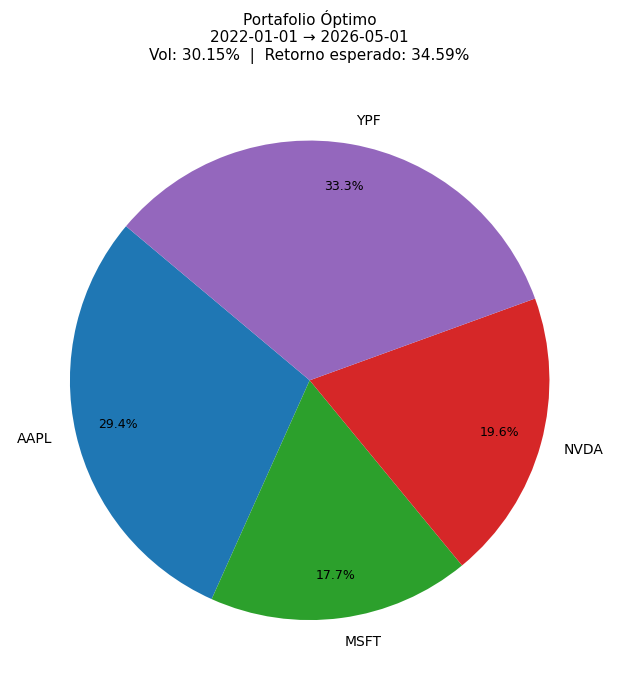

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import yfinance as yf


# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================

def descargar_datos(activos, inicio, fin):
    """Descarga precios de cierre y calcula retornos diarios."""
    datos_raw = yf.download(activos, start=inicio, end=fin, auto_adjust=True, progress=False)
    if len(activos) == 1:
        datos = datos_raw[['Close']]
        datos.columns = activos
    else:
        datos = datos_raw['Close']

    activos_faltantes = [a for a in activos if a not in datos.columns]
    if activos_faltantes:
        raise ValueError(f"No se encontraron datos para: {activos_faltantes}")

    datos = datos.dropna(axis=1, how='all')
    retornos = datos.pct_change().dropna()

    if retornos.empty:
        raise ValueError("No hay retornos válidos para el período ingresado.")

    return retornos


def covarianza_ledoit_wolf(retornos):
    """
    Estima la matriz de covarianza anualizada usando Ledoit-Wolf.
    Calcula el alpha óptimo automáticamente para reducir el ruido
    de estimación cuando hay pocos datos relativos a la cantidad de activos.
    """
    lw = LedoitWolf()
    lw.fit(retornos.values)
    cov_diaria = lw.covariance_
    cov_anual = cov_diaria * 252
    return cov_anual


def retornos_james_stein(retornos):
    """
    Estima los retornos esperados anualizados con shrinkage de James-Stein.

    El alpha se calcula a partir del tamaño muestral y la dispersión entre
    activos: con pocos datos relativos a la cantidad de activos, el promedio
    histórico individual es poco confiable, entonces se lo encoge hacia el
    promedio común de la cartera.

    Alpha = 0  → confia 100% en el promedio histórico individual
    Alpha = 1  → ignora el histórico, usa solo la referencia común
    """
    k = retornos.shape[1]           # número de activos
    T = retornos.shape[0]           # número de observaciones

    mu_hist = retornos.mean() * 252
    mu_ref = mu_hist.mean()         # referencia: promedio entre activos

    # Dispersión del promedio histórico alrededor de la referencia
    S = ((mu_hist - mu_ref) ** 2).sum()

    if S == 0:
        return mu_hist  # todos los activos tienen el mismo retorno, sin shrinkage

    # Fórmula de James-Stein: alpha óptimo dado T observaciones y k activos
    alpha = max(0.0, 1.0 - ((k - 2) / (T * S)))
    alpha = min(alpha, 0.95)  # techo para no anular completamente el histórico

    mu_js = (1 - alpha) * mu_hist + alpha * mu_ref

    return mu_js, alpha, mu_hist, mu_ref


def varianza_minima_global(cov_anual, n_activos):
    """
    Calcula la volatilidad mínima posible (portafolio GMV) dada la
    matriz de covarianza. Este valor es el piso para la varianza objetivo.
    """
    w0 = np.ones(n_activos) / n_activos
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, 1)] * n_activos

    sol = minimize(
        lambda w: w @ cov_anual @ w,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    vol_min = np.sqrt(sol.fun)
    return vol_min, sol.x


def optimizar_cartera(mu_js, cov_anual, vol_objetivo, n_activos):
    """
    Maximiza el retorno esperado (James-Stein) sujeto a:
      - Suma de pesos = 1
      - Volatilidad <= vol_objetivo
      - Pesos >= 0 (no short selling)
    """
    def func_obj(w):
        return -(w @ mu_js)

    def rest_presupuesto(w):
        return np.sum(w) - 1

    def rest_volatilidad(w):
        return vol_objetivo - np.sqrt(w @ cov_anual @ w)

    constraints = [
        {'type': 'eq',   'fun': rest_presupuesto},
        {'type': 'ineq', 'fun': rest_volatilidad}
    ]
    bounds = [(0, 1)] * n_activos
    w0 = np.ones(n_activos) / n_activos

    sol = minimize(func_obj, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    return sol


def grafico_torta(pesos, activos, vol_final, retorno_final, inicio, fin):
    """Gráfico de torta con ponderaciones de la cartera óptima."""
    # Filtra activos con peso > 0.5% para no saturar el gráfico
    umbral = 0.005
    pesos_graf = np.where(pesos > umbral, pesos, 0)
    labels = [a if p > umbral else '' for a, p in zip(activos, pesos)]

    fig, ax = plt.subplots(figsize=(7, 7))
    wedges, texts, autotexts = ax.pie(
        pesos_graf,
        labels=labels,
        autopct=lambda p: f'{p:.1f}%' if p > 0.5 else '',
        startangle=140,
        pctdistance=0.82
    )
    for t in autotexts:
        t.set_fontsize(9)

    ax.set_title(
        f'Portafolio Óptimo\n'
        f'{inicio} → {fin}\n'
        f'Vol: {vol_final:.2%}  |  Retorno esperado: {retorno_final:.2%}',
        fontsize=11, pad=15
    )
    plt.tight_layout()
    plt.show()


# =============================================================================
# FLUJO PRINCIPAL
# =============================================================================

print("=" * 55)
print("       OPTIMIZADOR DE CARTERA — MÉTODO ROBUSTO")
print("  (Ledoit-Wolf + James-Stein + Markowitz restringido)")
print("=" * 55)

# --- PASO 1: Inputs del usuario ---
tickers_input = input("\nIngrese los tickers separados por coma (ej: AAPL, MSFT, NVDA): ")
activos = [t.strip().upper() for t in tickers_input.split(",")]

inicio = input("Fecha de inicio (AAAA-MM-DD): ")
fin    = input("Fecha de fin   (AAAA-MM-DD): ")

try:
    # --- PASO 2: Descarga de datos ---
    print("\nDescargando datos...")
    retornos = descargar_datos(activos, inicio, fin)
    activos = list(retornos.columns)  # actualiza si yfinance descartó alguno
    n = len(activos)
    T = len(retornos)

    print(f"  Activos:       {activos}")
    print(f"  Observaciones: {T} días hábiles")

    # --- PASO 3: Covarianza Ledoit-Wolf ---
    cov_lw = covarianza_ledoit_wolf(retornos)
    vol_min, w_gmv = varianza_minima_global(cov_lw, n)

    print(f"\n--- Varianza mínima alcanzable (Ledoit-Wolf) ---")
    print(f"  Volatilidad mínima posible: {vol_min:.2%}")
    print(f"  (Cualquier valor por debajo no tiene solución)")

    # --- PASO 4: El usuario elige la varianza objetivo ---
    while True:
        try:
            vo_input = float(input(f"\nIngrese volatilidad objetivo en % (mínimo {vol_min*100:.2f}%): "))
            vol_objetivo = vo_input / 100
            if vol_objetivo < vol_min:
                print(f"  ⚠️  Debe ser mayor o igual a {vol_min*100:.2f}%. Intentá de nuevo.")
            else:
                break
        except ValueError:
            print("  Ingresá un número válido.")

    # --- PASO 5: Retornos James-Stein ---
    mu_js, alpha, mu_hist, mu_ref = retornos_james_stein(retornos)

    print(f"\n--- Estimación de retornos (James-Stein) ---")
    print(f"  Alpha de shrinkage: {alpha:.3f}  (0=histórico puro, 1=referencia pura)")
    print(f"  Retorno de referencia (promedio cartera): {mu_ref:.2%}")
    comparacion = pd.DataFrame({
        'Histórico puro': mu_hist.map('{:.2%}'.format),
        'James-Stein':    mu_js.map('{:.2%}'.format)
    })
    print(comparacion.to_string())

    # --- PASO 6: Optimización ---
    print(f"\n--- Optimizando con volatilidad objetivo: {vol_objetivo:.2%} ---")
    sol = optimizar_cartera(mu_js, cov_lw, vol_objetivo, n)

    if sol.success:
        pesos = sol.x
        vol_final     = np.sqrt(pesos @ cov_lw @ pesos)
        retorno_final = pesos @ mu_js

        print('\n--- PONDERACIONES ÓPTIMAS ---')
        resultado = pd.Series(pesos, index=activos)
        print(resultado.map('{:.2%}'.format).to_string())
        print(f'\nVolatilidad anualizada:      {vol_final:.2%}')
        print(f'Retorno esperado anualizado: {retorno_final:.2%}')
        print(f'Ratio de Sharpe (Rf=0):      {retorno_final/vol_final:.2f}')

        grafico_torta(pesos, activos, vol_final, retorno_final, inicio, fin)

    else:
        print(f'\n❌ No se encontró solución: {sol.message}')

except Exception as e:
    print(f"\n❌ Error: {e}")


--- Calculando frontera eficiente... ---


/tmp/ipykernel_6800/2784662438.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(vols_ind[i], mu_js[i],
/tmp/ipykernel_6800/2784662438.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.annotate(ticker, (vols_ind[i], mu_js[i]),


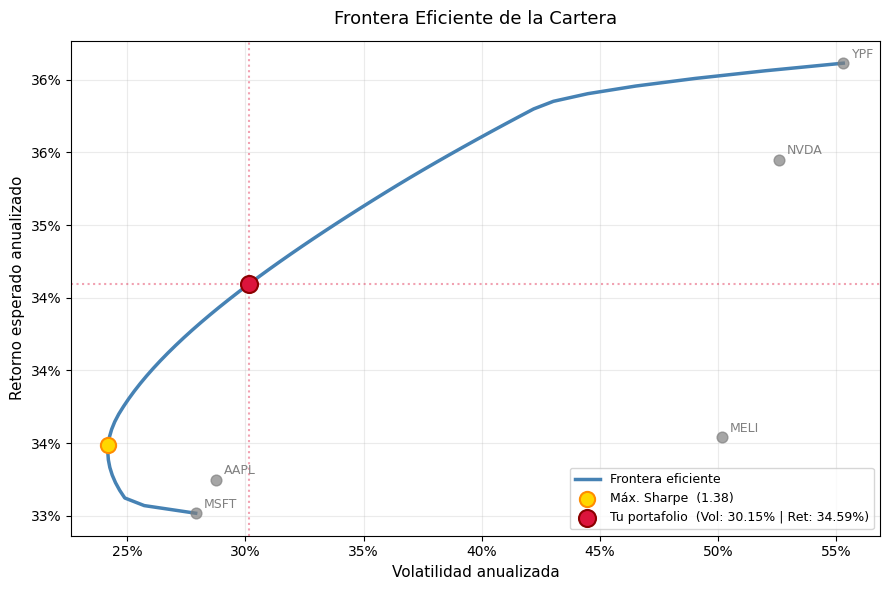

In [5]:
# =============================================================================
# FRONTERA EFICIENTE
# Requiere que estén definidos: mu_js, cov_lw, activos, pesos, vol_final,
# retorno_final (todos calculados en el script principal)
# =============================================================================

def calcular_frontera_eficiente(mu_js, cov_lw, n_activos, n_puntos=60):
    """
    Calcula la frontera eficiente barriendo retornos objetivo entre el
    retorno del portafolio GMV y el retorno máximo posible.
    Para cada retorno objetivo minimiza la varianza (enfoque dual de Markowitz).
    """
    # Rango de retornos objetivo: desde el GMV hasta el activo de mayor retorno
    ret_min = float(np.min(mu_js))
    ret_max = float(np.max(mu_js))
    retornos_objetivo = np.linspace(ret_min, ret_max, n_puntos)

    vols_frontera  = []
    rets_frontera  = []
    pesos_frontera = []

    w0 = np.ones(n_activos) / n_activos
    bounds = [(0, 1)] * n_activos

    for ret_obj in retornos_objetivo:
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w, r=ret_obj: w @ mu_js - r}
        ]
        sol = minimize(
            lambda w: w @ cov_lw @ w,
            w0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )
        if sol.success and sol.fun >= 0:
            vol = np.sqrt(sol.fun)
            vols_frontera.append(vol)
            rets_frontera.append(ret_obj)
            pesos_frontera.append(sol.x)

    return np.array(vols_frontera), np.array(rets_frontera), pesos_frontera


def grafico_frontera(vols_frontera, rets_frontera, vol_final, retorno_final,
                     mu_js, cov_lw, activos):
    """
    Grafica la frontera eficiente y marca:
      - Cada activo individual
      - El portafolio óptimo encontrado
      - El portafolio de máximo Sharpe (Rf = 0)
    """
    fig, ax = plt.subplots(figsize=(9, 6))

    # --- Frontera eficiente ---
    ax.plot(vols_frontera, rets_frontera,
            color='steelblue', linewidth=2.5, label='Frontera eficiente')

    # --- Activos individuales ---
    vols_ind = np.sqrt(np.diag(cov_lw))
    for i, ticker in enumerate(activos):
        ax.scatter(vols_ind[i], mu_js[i],
                   s=60, zorder=5, color='gray', alpha=0.7)
        ax.annotate(ticker, (vols_ind[i], mu_js[i]),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=9, color='gray')

    # --- Portafolio de máximo Sharpe (Rf=0) ---
    if len(vols_frontera) > 0:
        sharpes = rets_frontera / vols_frontera
        idx_max_sharpe = np.argmax(sharpes)
        ax.scatter(vols_frontera[idx_max_sharpe], rets_frontera[idx_max_sharpe],
                   s=120, color='gold', edgecolors='darkorange',
                   linewidth=1.5, zorder=6, label=f'Máx. Sharpe  ({sharpes[idx_max_sharpe]:.2f})')

    # --- Portafolio óptimo del usuario ---
    ax.scatter(vol_final, retorno_final,
               s=150, color='crimson', edgecolors='darkred',
               linewidth=1.5, zorder=7,
               label=f'Tu portafolio  (Vol: {vol_final:.2%} | Ret: {retorno_final:.2%})')

    # Línea punteada hacia los ejes para ubicarlo visualmente
    ax.axvline(x=vol_final, color='crimson', linestyle=':', alpha=0.4)
    ax.axhline(y=retorno_final, color='crimson', linestyle=':', alpha=0.4)

    # --- Formato ---
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_xlabel('Volatilidad anualizada', fontsize=11)
    ax.set_ylabel('Retorno esperado anualizado', fontsize=11)
    ax.set_title('Frontera Eficiente de la Cartera', fontsize=13, pad=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


# --- Ejecución ---
print("\n--- Calculando frontera eficiente... ---")
vols_f, rets_f, _ = calcular_frontera_eficiente(mu_js, cov_lw, n)
grafico_frontera(vols_f, rets_f, vol_final, retorno_final, mu_js, cov_lw, activos)